In [42]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re

In [2]:
TIME_RE = re.compile(r"([0-9]*\.?[0-9]*)\s*(s|ms|us|μs|ns)", re.IGNORECASE)
FILES = [f'results/results{i}.json' for i in range(0, 1200, 100)]

In [3]:
FILES

['results/results0.json',
 'results/results100.json',
 'results/results200.json',
 'results/results300.json',
 'results/results400.json',
 'results/results500.json',
 'results/results600.json',
 'results/results700.json',
 'results/results800.json',
 'results/results900.json',
 'results/results1000.json',
 'results/results1100.json']

In [4]:
def get_data(input_file):
    with open(input_file, "r", encoding="utf-8") as f:
        data = json.load(f)
    if not isinstance(data, list):
        raise ValueError("JSON file must contain a list at the top level.")
    return data

def save_data(data, file):
    with open(file, "w", encoding="utf-8") as out:
        json.dump(data, out, indent=2, ensure_ascii=False)

def split_data(data, chunk_size, outfiles):
    num_chunks = len(data) // chunk_size
    for i, file in zip(range(0, len(data), chunk_size), outfiles):
        chunk = data[i:i+chunk_size]
        save_data(chunk, file)


In [69]:
# fulldata = [datapoint for file in FILES for datapoint in get_data(file)]

In [250]:
pendings = 0
btimeouts = 0
vtimeouts = 0
gtothm = 0
gtocs = 0
bcsat = 0
vcsat = 0
gcsat = 0
ncsat = 0
for datapoint in fulldata:
    for test in datapoint['tests']:
        test = test['tests']
        gtime = test['proverfl']['time']
        gstatus = test['proverfl']['status']
        vtime = test['vampire']['time']
        vstatus = test['vampire']['status']
        if isinstance(datapoint['setting'], str) and datapoint['setting'] == 'Crafted':
            # continue
            pass
        elif isinstance(datapoint['setting'], dict) and 'RandTheorem' in datapoint['setting']:
            # continue
            pass
        elif isinstance(datapoint['setting'], dict) and 'RandDNF' in datapoint['setting']:
            # continue
            pass
        if vstatus == 'Pending' or gstatus == 'Pending':
            pendings += 1
        elif vstatus == 'Timedout' and gstatus == 'Timedout':
            btimeouts += 1
        elif vstatus == 'Timedout':
            vtimeouts += 1
        elif gstatus == 'Timedout' and vstatus == 'Theorem':
            gtothm += 1
        elif gstatus == 'Timedout' and vstatus == 'CounterSatisfiable':
            gtocs += 1
        elif vstatus == 'CounterSatisfiable' and gstatus == 'CounterSatisfiable':
            bcsat += 1
        elif vstatus == 'CounterSatisfiable':
            vcsat += 1
        elif gstatus == 'CounterSatisfiable':
            gcsat += 1
        else:
            ncsat += 1

In [251]:
values = [btimeouts, vtimeouts, gtothm, gtocs, bcsat, ncsat, vcsat, gcsat]
values, sum(values)

([2120, 1084, 831, 1954, 7150, 1261, 0, 0], 14400)

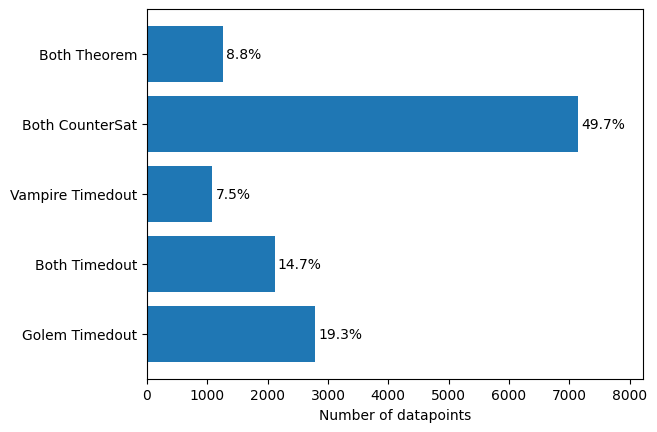

[2785, 2120, 1084, 7150, 1261]


In [252]:
labels = [*reversed(['Both Theorem', 'Both CounterSat', 'Vampire Timedout', 
    'Both Timedout', 'Golem Timedout'])]
values = [*reversed([ncsat, bcsat, vtimeouts, btimeouts, gtothm+ gtocs,])]

bars = plt.barh(labels, values)
plt.xlim(0, max(values) * 1.15)
plt.xlabel("Number of datapoints")
# plt.title("")

percentages = [v*100/sum(values) for v in values]

for bar, val, pct in zip(bars, values, percentages):
    plt.text(
        bar.get_width() + 50,
        bar.get_y() + bar.get_height()/2,
        f"{pct:.1f}%",
        va='center'
    )

plt.savefig("charts/correct_bar.png", dpi=300, bbox_inches="tight")
plt.show()
print(values)

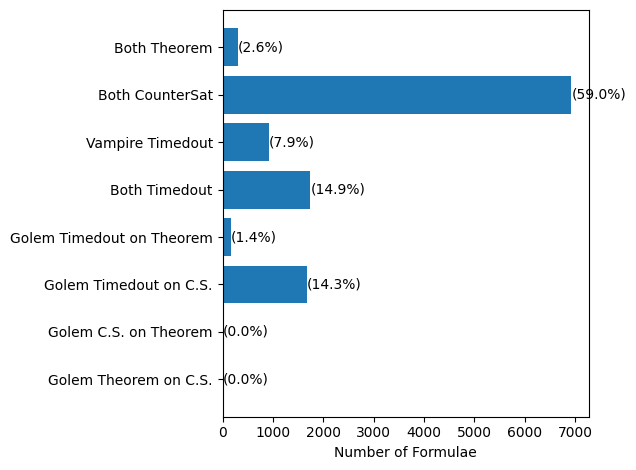

[0, 0, 1675, 168, 1743, 922, 6924, 304]


In [130]:
labels = [*reversed(['Both Theorem', 'Both CounterSat', 'Vampire Timedout', 
    'Both Timedout', 'Golem Timedout on Theorem', 'Golem Timedout on C.S.',
    'Golem C.S. on Theorem', 'Golem Theorem on C.S.'])]
values = [*reversed([ncsat, bcsat, vtimeouts,btimeouts,  gtothm, gtocs, vcsat, gcsat])]

bars = plt.barh(labels, values)
plt.xlabel("Number of Formulae")
# plt.title("")

percentages = [v*100/sum(values) for v in values]

for bar, val, pct in zip(bars, values, percentages):
    plt.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height()/2,
        f"({pct:.1f}%)",
        va='center'
    )

plt.tight_layout()
plt.savefig("charts/correct_bar_rdnf.png", dpi=300, bbox_inches="tight")
plt.show()
print(values)

In [280]:
pendings = 0
btimeouts = 0
vtogthm = 0
vtogcs = 0
gtovthm = 0
gtovcs = 0
gfastthm = 0
gfastcs = 0
vfastthm = 0
vfastcs = 0
for datapoint in fulldata:
    for test in datapoint['tests']:
        test = test['tests']
        gtime = test['proverfl']['time']
        gstatus = test['proverfl']['status']
        vtime = test['vampire']['time']
        vstatus = test['vampire']['status']
        if isinstance(datapoint['setting'], str) and datapoint['setting'] == 'Crafted':
            # continue
            pass
        elif isinstance(datapoint['setting'], dict) and 'RandTheorem' in datapoint['setting']:
            # continue
            pass
        elif isinstance(datapoint['setting'], dict) and 'RandDNF' in datapoint['setting']:
            # continue
            pass
        if vstatus == 'Pending' or gstatus == 'Pending':
            pendings += 1
        elif vstatus == 'Timedout' and gstatus == 'Timedout':
            btimeouts += 1
        elif vstatus == 'Timedout' and gstatus == 'Theorem':
            vtogthm += 1
        elif vstatus == 'Timedout' and gstatus == 'CounterSatisfiable':
            vtogcs += 1
        elif gstatus == 'Timedout' and vstatus == 'Theorem':
            gtovthm += 1
        elif gstatus == 'Timedout' and vstatus == 'CounterSatisfiable':
            gtovcs += 1
        elif vstatus == 'CounterSatisfiable' and gstatus == 'CounterSatisfiable' and vtime < gtime:
            vfastcs += 1
        elif vstatus == 'CounterSatisfiable' and gstatus == 'CounterSatisfiable' and gtime < vtime:
            gfastcs += 1
        elif vstatus == 'Theorem' and gstatus == 'Theorem' and vtime < gtime:
            vfastthm += 1
        elif vstatus == 'Theorem' and gstatus == 'Theorem' and gtime < vtime:
            gfastthm += 1

In [281]:
values = [pendings, btimeouts, vtogthm, vtogcs, gtovthm, gtovcs, gfastthm, gfastcs, vfastthm, vfastcs]
values, sum(values)

([0, 2120, 134, 950, 831, 1954, 1046, 6183, 215, 967], 14400)

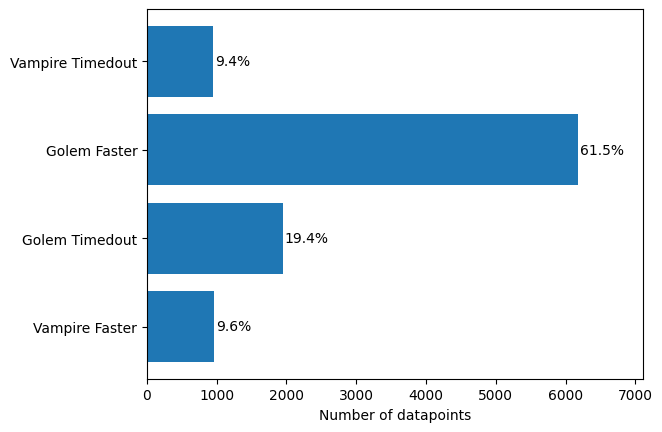

[967, 1954, 6183, 950]


In [282]:
labels = [*reversed([
    'Vampire Timedout', 'Golem Faster',
    # 'Both Timedout',
    'Golem Timedout', 'Vampire Faster'])]
# values = [*reversed([vtogthm+ vtogcs, gfastthm+ gfastcs, btimeouts, gtovthm+ gtovcs, vfastthm+ vfastcs])]
values = [*reversed([vtogcs, gfastcs, gtovcs, vfastcs])]
# values = [*reversed([vtogthm, gfastthm, gtovthm, vfastthm])]

bars = plt.barh(labels, values)
plt.xlim(0, max(values) * 1.15)
plt.xlabel("Number of datapoints")
# plt.title("")

percentages = [v*100/sum(values) for v in values]

for bar, val, pct in zip(bars, values, percentages):
    plt.text(
        bar.get_width() + 20,
        bar.get_y() + bar.get_height()/2,
        f"{pct:.1f}%",
        va='center'
    )


plt.savefig("charts/speed_bar_csats.png", dpi=300, bbox_inches="tight")
plt.show()
print(values)

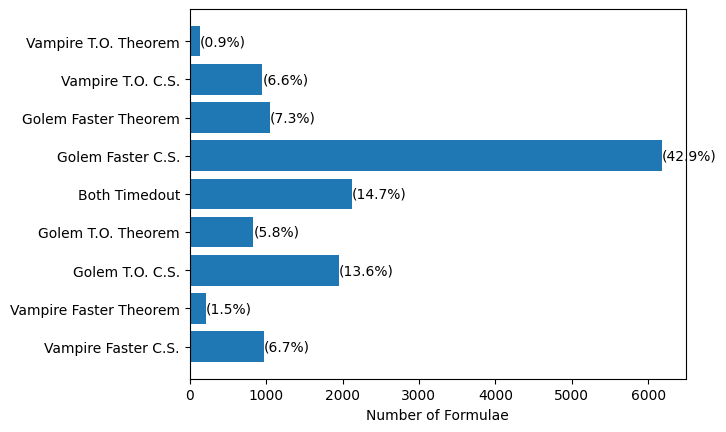

[967, 215, 1954, 831, 2120, 6183, 1046, 950, 134]


In [141]:
labels = [*reversed([
    'Vampire T.O. Theorem', 'Vampire T.O. C.S.', 'Golem Faster Theorem', 'Golem Faster C.S.',
    'Both Timedout',
    'Golem T.O. Theorem', 'Golem T.O. C.S.', 'Vampire Faster Theorem', 'Vampire Faster C.S.',])]
values = [*reversed([vtogthm, vtogcs, gfastthm, gfastcs, btimeouts, gtovthm, gtovcs, vfastthm, vfastcs])]

bars = plt.barh(labels, values)
plt.xlim(0, max(values) * 1.15)
plt.xlabel("Number of Formulae")
# plt.title("")

percentages = [v*100/sum(values) for v in values]

for bar, val, pct in zip(bars, values, percentages):
    plt.text(
        bar.get_width() + 5,
        bar.get_y() + bar.get_height()/2,
        f"{pct:.1f}%",
        va='center'
    )


plt.savefig("charts/speed_bar_all.png", dpi=300, bbox_inches="tight")
plt.show()
print(values)

In [248]:
def compare_times(data, key1, key2):
    values1 = [test['tests'][key1]['time'] for datapoint in data for test in datapoint['tests']]
    values2 = [test['tests'][key2]['time'] for datapoint in data for test in datapoint['tests']]
    values = [v1 / v2 for v1, v2 in zip(values1, values2) if v1 is not None and v2 is not None]
    values = np.array(values, dtype=np.float64)
    log_vals = np.log(values)
    gmean = np.exp(np.mean(log_vals))
    median = np.median(values)
    print("Geometric mean:", gmean)
    bins = np.logspace(np.log10(values.min()), np.log10(values.max()), 50)
    plt.hist(values, bins=bins)
    plt.xscale("log")
    plt.axvline(gmean, color="green", linestyle=":", label=f"Geom mean {gmean:.3g}")
    plt.axvline(median, color="red", linestyle="--", label=f"Median {median:.3g}")
    plt.axvline(1, color="black", linestyle="-", label="1")
    plt.legend()
    plt.show()


In [283]:
vtimes = []
gtimes = []
for datapoint in fulldata:
    for test in datapoint['tests']:
        test = test['tests']
        gtime = test['proverfl']['time']
        gstatus = test['proverfl']['status']
        vtime = test['vampire']['time']
        vstatus = test['vampire']['status']
        if isinstance(datapoint['setting'], str) and datapoint['setting'] == 'Crafted':
            # continue
            pass
        elif isinstance(datapoint['setting'], dict) and 'RandTheorem' in datapoint['setting']:
            # continue
            pass
        elif isinstance(datapoint['setting'], dict) and 'RandDNF' in datapoint['setting']:
            # continue
            pass
        if vstatus == 'Pending' or vstatus == 'Timedout' or gstatus == 'Pending' or gstatus == 'Timedout':
            pass
        if vstatus == 'Theorem' or gstatus == 'Theorem':
            continue
            pass
        elif vstatus == 'CounterSatisfiable' or gstatus == 'CounterSatisfiable':
            # continue
            pass
        if gstatus != 'Timedout' and vstatus != 'Timedout':
            gtimes.append(gtime)
            vtimes.append(vtime)
        # if vstatus != 'Timedout':
len(vtimes), len(gtimes)

(7150, 7150)

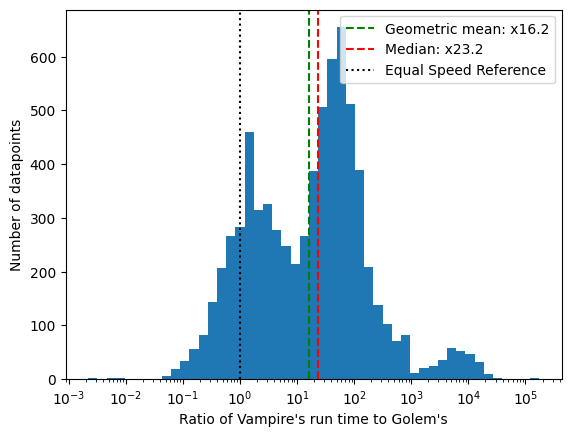

In [284]:
values = [vt / gt for vt, gt in zip(vtimes, gtimes)]
values = np.array(values, dtype=np.float64)
log_vals = np.log(values)
gmean = np.exp(np.mean(log_vals))
median = np.median(values)
bins = np.logspace(np.log10(values.min()), np.log10(values.max()), 50)
plt.hist(values, bins=bins)
plt.xscale("log")
plt.xlabel("Ratio of Vampire's run time to Golem's")
plt.ylabel("Number of datapoints")
plt.axvline(gmean, color="green", linestyle="--", label=f"Geometric mean: x{gmean:.3g}")
plt.axvline(median, color="red", linestyle="--", label=f"Median: x{median:.3g}")
plt.axvline(1, color="black", linestyle=":", label="Equal Speed Reference")
plt.legend()
plt.savefig("charts/speed_hist_csats.png", dpi=300)
plt.show()

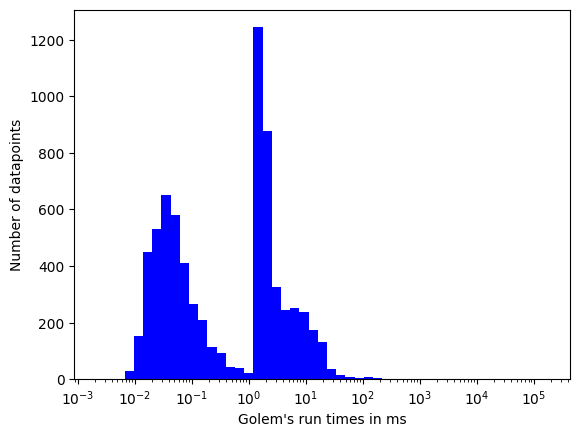

In [285]:
bins = np.logspace(np.log10(values.min()), np.log10(values.max()), 50)
plt.hist(gtimes, bins=bins, color='blue')
plt.xlabel("Golem's run times in ms")
plt.ylabel("Number of datapoints")
# plt.hist(gtimes, bins=bins, alpha=0.2, color='red', label='Data 2')
plt.xscale("log")
# plt.savefig("charts/time_hist.png", dpi=300)
plt.show()

In [180]:
pendings = 0
btimeouts = 0
vtogthm = 0
vtogcs = 0
gtovthm = 0
gtovcs = 0
gfastthm = 0
gfastcs = 0
vfastthm = 0
vfastcs = 0
for i, datapoint in enumerate(fulldata):
    for test in datapoint['tests']:
        frames = test['frames']
        test = test['tests']
        gtime = test['proverfl']['time']
        gstatus = test['proverfl']['status']
        vtime = test['vampire']['time']
        vstatus = test['vampire']['status']
        if frames in [
            # 'K',
            # 'D',
            # 'T',
            # 'KB',
            # 'DB',
            # 'TB',
            # 'K5',
            # 'D5',
            # 'K45',
            # 'D45',
            # 'KB5',
            # 'S5',
        ]:
            continue
            pass
        if isinstance(datapoint['setting'], str) and datapoint['setting'] == 'Crafted':
            continue
            pass
        elif isinstance(datapoint['setting'], dict) and 'RandTheorem' in datapoint['setting']:
            continue
            pass
        elif isinstance(datapoint['setting'], dict) and 'RandDNF' in datapoint['setting']:
            # continue
            if i % 2 == 0:
                # continue
                pass
            else:
                continue
                pass
            if datapoint['setting']['RandDNF']['disj_size'] == 5:
                continue
                pass
            elif datapoint['setting']['RandDNF']['disj_size'] == 4:
                continue
                pass
            elif datapoint['setting']['RandDNF']['disj_size'] == 3:
                continue
                pass
            elif datapoint['setting']['RandDNF']['disj_size'] == 2:
                # continue
                pass
            pass
        if vstatus == 'Pending' or gstatus == 'Pending':
            pendings += 1
        elif vstatus == 'Timedout' and gstatus == 'Timedout':
            btimeouts += 1
        elif vstatus == 'Timedout' and gstatus == 'Theorem':
            vtogthm += 1
        elif vstatus == 'Timedout' and gstatus == 'CounterSatisfiable':
            vtogcs += 1
        elif gstatus == 'Timedout' and vstatus == 'Theorem':
            gtovthm += 1
        elif gstatus == 'Timedout' and vstatus == 'CounterSatisfiable':
            gtovcs += 1
        elif vstatus == 'CounterSatisfiable' and gstatus == 'CounterSatisfiable' and vtime < gtime:
            vfastcs += 1
        elif vstatus == 'CounterSatisfiable' and gstatus == 'CounterSatisfiable' and gtime < vtime:
            gfastcs += 1
        elif vstatus == 'Theorem' and gstatus == 'Theorem' and vtime < gtime:
            vfastthm += 1
        elif vstatus == 'Theorem' and gstatus == 'Theorem' and gtime < vtime:
            gfastthm += 1
values = [pendings, btimeouts, vtogthm, vtogcs, gtovthm, gtovcs, gfastthm, gfastcs, vfastthm, vfastcs]
values, sum(values)

([0, 81, 0, 135, 26, 216, 52, 1103, 4, 243], 1860)

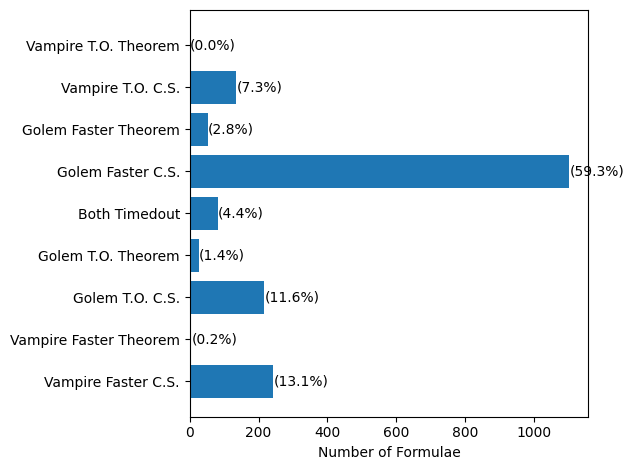

[243, 4, 216, 26, 81, 1103, 52, 135, 0]


In [181]:
labels = [*reversed([
    'Vampire T.O. Theorem', 'Vampire T.O. C.S.', 'Golem Faster Theorem', 'Golem Faster C.S.',
    'Both Timedout',
    'Golem T.O. Theorem', 'Golem T.O. C.S.', 'Vampire Faster Theorem', 'Vampire Faster C.S.',])]
values = [*reversed([vtogthm, vtogcs, gfastthm, gfastcs, btimeouts, gtovthm, gtovcs, vfastthm, vfastcs])]

bars = plt.barh(labels, values)
plt.xlabel("Number of Formulae")
# plt.title("")

percentages = [v*100/sum(values) for v in values]

for bar, val, pct in zip(bars, values, percentages):
    plt.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height()/2,
        f"({pct:.1f}%)",
        va='center'
    )

plt.tight_layout()
plt.savefig("charts/speed_bar_disj2.png", dpi=300, bbox_inches="tight")
plt.show()
print(values)

In [ ]:
pendings = 0
btimeouts = 0
vtogthm = 0
vtogcs = 0
gtovthm = 0
gtovcs = 0
gfastthm = 0
gfastcs = 0
vfastthm = 0
vfastcs = 0
for i, datapoint in enumerate(fulldata):
    for test in datapoint['tests']:
        frames = test['frames']
        test = test['tests']
        gtime = test['proverfl']['time']
        gstatus = test['proverfl']['status']
        vtime = test['vampire']['time']
        vstatus = test['vampire']['status']
        if frames in [
            # 'K',
            # 'D',
            # 'T',
            # 'KB',
            # 'DB',
            # 'TB',
            # 'K5',
            # 'D5',
            # 'K45',
            # 'D45',
            # 'KB5',
            # 'S5',
        ]:
            continue
            pass
        if isinstance(datapoint['setting'], str) and datapoint['setting'] == 'Crafted':
            # continue
            pass
        elif isinstance(datapoint['setting'], dict) and 'RandTheorem' in datapoint['setting']:
            # continue
            pass
        elif isinstance(datapoint['setting'], dict) and 'RandDNF' in datapoint['setting']:
            # continue
            if i % 2 == 0:
                # continue
                pass
            else:
                continue
                pass
            if datapoint['setting']['RandDNF']['disj_size'] == 5:
                continue
                pass
            elif datapoint['setting']['RandDNF']['disj_size'] == 4:
                continue
                pass
            elif datapoint['setting']['RandDNF']['disj_size'] == 3:
                # continue
                pass
            elif datapoint['setting']['RandDNF']['disj_size'] == 2:
                continue
                pass
            pass
        if vstatus == 'Pending' or gstatus == 'Pending':
            pendings += 1
        elif vstatus == 'Timedout' and gstatus == 'Timedout':
            btimeouts += 1
        elif vstatus == 'Timedout' and gstatus == 'Theorem':
            vtogthm += 1
        elif vstatus == 'Timedout' and gstatus == 'CounterSatisfiable':
            vtogcs += 1
        elif gstatus == 'Timedout' and vstatus == 'Theorem':
            gtovthm += 1
        elif gstatus == 'Timedout' and vstatus == 'CounterSatisfiable':
            gtovcs += 1
        elif vstatus == 'CounterSatisfiable' and gstatus == 'CounterSatisfiable' and vtime < gtime:
            vfastcs += 1
        elif vstatus == 'CounterSatisfiable' and gstatus == 'CounterSatisfiable' and gtime < vtime:
            gfastcs += 1
        elif vstatus == 'Theorem' and gstatus == 'Theorem' and vtime < gtime:
            vfastthm += 1
        elif vstatus == 'Theorem' and gstatus == 'Theorem' and gtime < vtime:
            gfastthm += 1
values = [pendings, btimeouts, vtogthm, vtogcs, gtovthm, gtovcs, gfastthm, gfastcs, vfastthm, vfastcs]
values, sum(values)

In [ ]:
labels = [*reversed([
    'Vampire T.O. Theorem', 'Vampire T.O. C.S.', 'Golem Faster Theorem', 'Golem Faster C.S.',
    'Both Timedout',
    'Golem T.O. Theorem', 'Golem T.O. C.S.', 'Vampire Faster Theorem', 'Vampire Faster C.S.',])]
values = [*reversed([vtogthm, vtogcs, gfastthm, gfastcs, btimeouts, gtovthm, gtovcs, vfastthm, vfastcs])]

bars = plt.barh(labels, values)
plt.xlabel("Number of Formulae")
# plt.title("")

percentages = [v*100/sum(values) for v in values]

for bar, val, pct in zip(bars, values, percentages):
    plt.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height()/2,
        f"({pct:.1f}%)",
        va='center'
    )

plt.tight_layout()
plt.savefig("charts/speed_bar_disj3.png", dpi=300, bbox_inches="tight")
plt.show()
print(values)

In [207]:
xs = {}
vs = {}
for i, datapoint in enumerate(fulldata):
    for test in datapoint['tests']:
        frames = test['frames']
        test = test['tests']
        gtime = test['proverfl']['time']
        gstatus = test['proverfl']['status']
        vtime = test['vampire']['time']
        vstatus = test['vampire']['status']
        if frames in [
            # 'K',
            # 'D',
            # 'T',
            # 'KB',
            # 'DB',
            # 'TB',
            # 'K5',
            # 'D5',
            # 'K45',
            # 'D45',
            # 'KB5',
            # 'S5',
        ]:
            continue
            pass
        if isinstance(datapoint['setting'], str) and datapoint['setting'] == 'Crafted':
            # continue
            pass
        elif isinstance(datapoint['setting'], dict) and 'RandTheorem' in datapoint['setting']:
            # continue
            pass
        elif isinstance(datapoint['setting'], dict) and 'RandDNF' in datapoint['setting']:
            # continue
            if i % 2 == 0:
                # continue
                pass
            else:
                # continue
                pass
            if datapoint['setting']['RandDNF']['disj_size'] == 5:
                # continue
                pass
            elif datapoint['setting']['RandDNF']['disj_size'] == 4:
                # continue
                pass
            elif datapoint['setting']['RandDNF']['disj_size'] == 3:
                # continue
                pass
            elif datapoint['setting']['RandDNF']['disj_size'] == 2:
                # continue
                pass
            pass
        if vstatus == 'Pending' or gstatus == 'Pending':
            pendings += 1
        elif vstatus == 'Timedout' and gstatus == 'Timedout':
            btimeouts += 1
        elif vstatus == 'Timedout' and gstatus == 'Theorem':
            vtogthm += 1
        elif vstatus == 'Timedout' and gstatus == 'CounterSatisfiable':
            vtogcs += 1
        elif gstatus == 'Timedout' and vstatus == 'Theorem':
            gtovthm += 1
        elif gstatus == 'Timedout' and vstatus == 'CounterSatisfiable':
            gtovcs += 1
        elif vstatus == 'CounterSatisfiable' and gstatus == 'CounterSatisfiable' and vtime < gtime:
            vfastcs += 1
        elif vstatus == 'CounterSatisfiable' and gstatus == 'CounterSatisfiable' and gtime < vtime:
            gfastcs += 1
        elif vstatus == 'Theorem' and gstatus == 'Theorem' and vtime < gtime:
            vfastthm += 1
        elif vstatus == 'Theorem' and gstatus == 'Theorem' and gtime < vtime:
            gfastthm += 1
        if gstatus == 'Timedout':
            continue
        # x = datapoint['setting']['RandDNF']['disj_size']
        # x = datapoint['setting']['RandDNF']['num_props']
        x = len(datapoint['formula'])
        if x not in xs:
            xs[x] = []
        xs[x].append(gtime)
# values = [pendings, btimeouts, vtogthm, vtogcs, gtovthm, gtovcs, gfastthm, gfastcs, vfastthm, vfastcs]
# values, sum(values)
sum(len(ys) for ys in xs.values())

9495

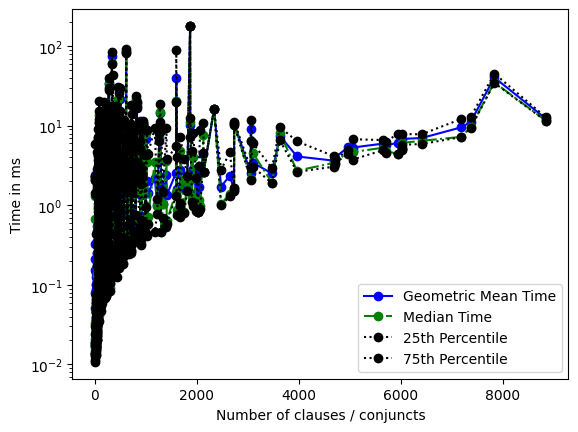

In [208]:
xvals = sorted([x for x in xs])
y_nested = [np.array(xs[x]) for x in xvals]
log_y_mean = [np.mean(np.log10(y)) for y in y_nested]
y_medns = [np.median(y) for y in y_nested]
y_25 = [np.percentile(y, 25) for y in y_nested]
y_75 = [np.percentile(y, 75) for y in y_nested]

# plt.errorbar(
#     xvals, 10**np.array(log_y_mean), yerr=y_err,
#     fmt='o-', capsize=5, ecolor='red'
# )

plt.plot(xvals, 10**np.array(log_y_mean), marker='o', linestyle='-', color='blue', label='Geometric Mean Time')
plt.plot(xvals, y_medns, marker='o', linestyle='-.', color='green', label='Median Time')
plt.plot(xvals, y_25, marker='o', linestyle=':', color='black', label='25th Percentile')
plt.plot(xvals, y_75, marker='o', linestyle=':', color='black', label='75th Percentile')

plt.yscale('log')
plt.xlabel("Number of clauses / conjuncts")
plt.ylabel("Time in ms")
plt.legend()
plt.savefig("charts/speed_line_len.png", dpi=300, bbox_inches="tight")
plt.show()


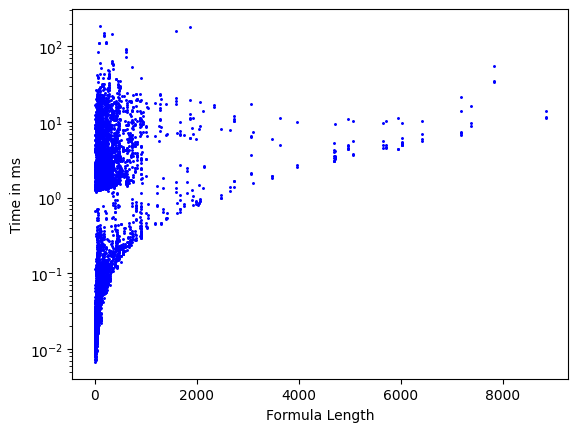

In [212]:
xyvals = [(x, y) for x in xs for y in xs[x]]
xvals = [x for x,y in xyvals]
yvals = [y for x,y in xyvals]
y_nested = [np.array(xs[x]) for x in xvals]
log_y_mean = [np.mean(np.log10(y)) for y in y_nested]
y_medns = [np.median(y) for y in y_nested]
y_25 = [np.percentile(y, 25) for y in y_nested]
y_75 = [np.percentile(y, 75) for y in y_nested]

# plt.errorbar(
#     xvals, 10**np.array(log_y_mean), yerr=y_err,
#     fmt='o-', capsize=5, ecolor='red'
# )

plt.scatter(xvals, yvals, marker='.', s=5, color='blue')

plt.yscale('log')
plt.xlabel("Formula Length")
plt.ylabel("Time in ms")
# plt.legend()
plt.savefig("charts/speed_sctr_len.png", dpi=300, bbox_inches="tight")
plt.show()


In [187]:
y_nested

[array([0.12050100000000001, 8.703, None, ..., 0.033269, 0.037626,
        0.057829], shape=(3720,), dtype=object),
 array([0.047333, 0.033363, 0.041026, ..., None, None, None],
       shape=(3984,), dtype=object),
 array([3.435, 3.268, 10.301, ..., 0.017550999999999997, 0.021962,
        0.017443], shape=(4032,), dtype=object)]

In [28]:
def change_subtests(inputfiles):
    for file in inputfiles:
        data = get_data(file)
        for datapoint in data:
            for test in datapoint['tests']:
                test['tests'] = {
                    'vampire': {
                        'status': test['vampirestatus'],
                        'time': test['vampiretime'],
                    },
                    'prover': {
                        'status': test['proverstatus'],
                        'time': test['provertime'],
                    },
                }
                del test['vampirestatus']
                del test['vampiretime']
                del test['proverstatus']
                del test['provertime']
        save_data(data, file)


In [199]:
def parse_times(data):
    for datapoint in data:
        for test in datapoint['tests']:
            for subtest in test['tests'].values():
                subtest['time'] = parse_time(subtest['status'], subtest['time'])

def parse_time(status, time_str):
    if status == "Pending" or time_str is None:
        return None
    time_str = time_str.strip().lower()
    if time_str == "none" or time_str == "null":
        return None
    m = TIME_RE.fullmatch(time_str)
    if not m:
        raise ValueError(f"Invalid time format: {time_str}")
    num = float(m.group(1))
    unit = m.group(2).lower()
    if unit == "s":
        ms = num * 1000
    elif unit == "ms":
        ms = num
    elif unit == "us" or unit == "µs":
        ms = num / 1000
    elif unit == "ns":
        ms = num / 1_000_000
    else:
        raise ValueError(f"Unknown unit: {unit} cmp µs")
    if ms == 0.0:
        ms = 0.01
    if status in ["Timedout"]:
        return None
    return ms

def compare_times(data, key1, key2):
    values1 = [test['tests'][key1]['time'] for datapoint in data for test in datapoint['tests']]
    values2 = [test['tests'][key2]['time'] for datapoint in data for test in datapoint['tests']]
    values = [v1 / v2 for v1, v2 in zip(values1, values2) if v1 is not None and v2 is not None]
    values = np.array(values, dtype=np.float64)
    log_vals = np.log(values)
    gmean = np.exp(np.mean(log_vals))
    median = np.median(values)
    print("Geometric mean:", gmean)
    bins = np.logspace(np.log10(values.min()), np.log10(values.max()), 50)
    plt.hist(values, bins=bins)
    plt.xscale("log")
    plt.axvline(gmean, color="green", linestyle=":", label=f"Geom mean {gmean:.3g}")
    plt.axvline(median, color="red", linestyle="--", label=f"Median {median:.3g}")
    plt.axvline(1, color="black", linestyle="-", label="1")
    plt.legend()
    plt.show()


In [13]:
for data in fulldata:
    parse_times(data)

Geometric mean: 16.712924791718944


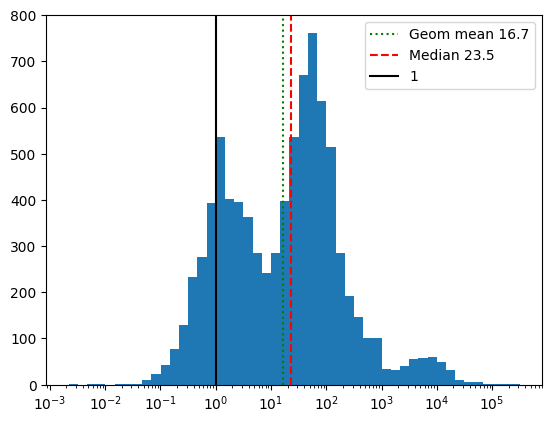

In [37]:
compare_times(fulldata, "vampire", "proverfl")